03 · Centrality, clustering and communities

Six SciGraphs operators answer *which nodes matter, and which nodes belong
together*:

| Operator | Domain | Writes |
|---|---|---|
| `scigraphs.calculate_centrality` | undirected | `centrality_<method>` |
| `scigraphs.calculate_directed_centrality` | directed only | `directed_<method>` |
| `scigraphs.calculate_clustering` | undirected | `clustering` |
| `scigraphs.apply_clustering` | undirected | `cluster_id`, `cluster_size`, `node_clustering`, `modularity`, `surprise` |
| `scigraphs.find_sccs` | directed only | `scc_id` |
| `scigraphs.detect_patterns` | directed only | `pattern_*` object properties |

Several do something other than what their label says, and one cannot be run
at all with its default settings.

The graphs are abstract and seeded, from NetworkX generators: Zachary's
karate club, a Barabási-Albert graph and a directed scale-free graph. No
network access, no maps; **18** is the geospatial case study. **15** gets
graphs into Blender, **16** lays them out, **18** does paths, trees and
flows, **19** does topology.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import itertools
import json

import bpy
import networkx as nx
import numpy as np

from scipy.stats import spearmanr

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

from scigraphs_core import analysis
from scigraphs_core.mesh.mesh_utils import parse_graph_data_filtered

sg.graphs.clear_scene(keep_anchor=False)

# Without this wheel `detect_communities` falls back to networkx greedy
# modularity and every partition from section 9 on changes.
try:
    import pysurprise  # noqa: F401
    HAVE_PYSURPRISE = True
except ImportError:
    HAVE_PYSURPRISE = False
check("the pySurprise community backends are installed", HAVE_PYSURPRISE,
      "without them section 9 measures the networkx fallback instead")

[PASS] the pySurprise community backends are installed — without them section 9 measures the networkx fallback instead


True

## 1 · Three graphs, built once and never moved

These operators want a *graph object*: a mesh whose vertices are the nodes
and whose `mesh.edges` are the edges, with `num_nodes` / `num_edges` /
`is_directed` as custom properties. That is the mesh-native format
`scripts/showcase/build_showcase.py` writes; the legacy alternative is the
`nodes_data` / `edges_data` name strings from the GeoDataFrame importers.
`parse_graph_data_filtered()` reads both, and every analysis operator goes
through it.

* Positions are computed once and reused, so a node lands in the same place
  on all ten plates. `nx.spring_layout` is seeded here; the add-on's default
  layout is not (`SciGraphs/core/mesh/layouts/networkx_layouts.py:8` and
  `:18` call it with no `seed=`).
* Nothing lays the graph out after it is built. The layout operators go
  through `rebuild_edges`, which deletes and recreates every mesh edge
  (`SciGraphs/core/mesh/geometry.py:1227` to `:1248`), taking any EDGE-domain
  attribute with it. Everything here is node-valued and would survive, but
  *import, lay out, then measure* is the safe order in general.

In [2]:
def to_blender(graph, name, seed, spread, directed=False, coll="Abstract"):
    """A NetworkX graph as a mesh-native SciGraphs object, laid out once."""
    order = list(graph.nodes())
    index = {node: i for i, node in enumerate(order)}
    positions = nx.spring_layout(graph.to_undirected(), seed=seed)
    coords = np.array([[positions[n][0] * spread, positions[n][1] * spread, 0.0]
                      for n in order], dtype=np.float32)
    edges = np.array([[index[u], index[v]] for u, v in graph.edges()],
                     dtype=np.int32)

    mesh = bpy.data.meshes.new(name)
    mesh.vertices.add(len(order))
    mesh.vertices.foreach_set("co", coords.ravel())
    mesh.edges.add(len(edges))
    mesh.edges.foreach_set("vertices", edges.ravel())
    mesh.update()

    obj = bpy.data.objects.new(name, mesh)
    obj["num_nodes"] = len(order)
    obj["num_edges"] = len(edges)
    obj["is_directed"] = bool(directed)
    obj["node_names"] = json.dumps([str(n) for n in order])
    sg.graphs.collection(coll).objects.link(obj)
    return obj, order


KARATE = nx.karate_club_graph()
karate, karate_order = to_blender(KARATE, "Karate", seed=7, spread=10.0)

SCALEFREE = nx.barabasi_albert_graph(150, 2, seed=17)
scalefree, scalefree_order = to_blender(SCALEFREE, "BarabasiAlbert",
                                        seed=11, spread=13.0)

DIRECTED = nx.DiGraph(nx.scale_free_graph(120, seed=4))
DIRECTED.remove_edges_from(nx.selfloop_edges(DIRECTED))
directed, directed_order = to_blender(DIRECTED, "DirectedScaleFree",
                                      seed=5, spread=12.0, directed=True)

for obj in (karate, scalefree, directed):
    print(f"{obj.name:20} {obj['num_nodes']:>4} nodes  {obj['num_edges']:>4} edges  "
          f"directed={bool(obj['is_directed'])}")

Karate                 34 nodes    78 edges  directed=False
BarabasiAlbert        150 nodes   296 edges  directed=False
DirectedScaleFree     120 nodes   197 edges  directed=True


The operators see only what `parse_graph_data_filtered()`
reconstructs from the mesh. Edge order survives: Blender stores a mesh edge
as the ordered pair it was given.

In [3]:
parsed = {obj.name: parse_graph_data_filtered(obj)
          for obj in (karate, scalefree, directed)}

check("the mesh round-trips every node and edge",
      all(len(parsed[o.name].nodes) == o["num_nodes"]
      and len(parsed[o.name].edges) == o["num_edges"]
      for o in (karate, scalefree, directed)))

oriented = sum(1 for (a, b), (u, v)
               in zip(parsed["DirectedScaleFree"].edges, DIRECTED.edges())
               if (a, b) == (str(u), str(v)))
check("edge direction survives the mesh",
      oriented == DIRECTED.number_of_edges(),
      f"{oriented}/{DIRECTED.number_of_edges()} pairs in the original order")

[PASS] the mesh round-trips every node and edge
[PASS] edge direction survives the mesh — 197/197 pairs in the original order


True

## 2 · What `calculate_centrality` actually computes

Four methods (`analysis_operators.py:26` to `:35`, scene property at
`splitter_properties.py:229`), each a one-line call into NetworkX. The
interesting part is the two lines above them:

```python
G = nx.Graph()                                   # analysis.py:16
G.add_nodes_from(range(len(graph_data.nodes)))
```

`nx.Graph`, unconditionally, whatever `is_directed` says, so a directed graph
is silently symmetrized; section 6 measures the cost. And no weights: edges
go in as bare index pairs, because `GraphData` carries only `nodes`, `edges`
and an optional dataframe (`SciGraphs/core/algorithms/graph.py:3`). So
`betweenness` counts shortest paths in *hops* and `closeness` is a hop
distance, on every graph, always. On a street network, where edge lengths are
the entire point, that is not the quantity the label implies.

* `degree`: neighbors over `n - 1`, and free to compute.
* `betweenness`: the share of all shortest paths passing *through* the node.
  A bridge scores high on two neighbors.
* `closeness`: reciprocal of the mean hop distance to everyone else.
* `eigenvector`: degree, weighted recursively by the neighbors' scores.

In [4]:
sg.graphs.activate(karate)
METHODS = ("degree", "betweenness", "closeness", "eigenvector")

for method in METHODS:
    result = bpy.ops.scigraphs.calculate_centrality(method=method)
    print(f"{method:14} {'/'.join(result):10} ->  centrality_{method}")

print("\nattributes on", karate.name)
for name, domain, dtype in sg.graphs.attributes(karate):
    if not name.startswith("."):
        print(f"  {name:<26} {domain:<7} {dtype}")

Info: Centrality 'degree' calculated
degree         FINISHED   ->  centrality_degree
Info: Centrality 'betweenness' calculated
betweenness    FINISHED   ->  centrality_betweenness
Info: Centrality 'closeness' calculated
closeness      FINISHED   ->  centrality_closeness
Info: Centrality 'eigenvector' calculated
eigenvector    FINISHED   ->  centrality_eigenvector

attributes on Karate
  position                   POINT   FLOAT_VECTOR
  centrality_degree          POINT   FLOAT
  centrality_betweenness     POINT   FLOAT
  centrality_closeness       POINT   FLOAT
  centrality_eigenvector     POINT   FLOAT


The values come from the core function, so the notebook can do
arithmetic with them. They match NetworkX exactly: the operator adds a
Blender attribute and changes nothing.

In [5]:
karate_gd = parsed["Karate"]
centrality = {m: np.array(analysis.calculate_centrality(karate_gd, method=m))
              for m in METHODS}

reference = np.array([nx.betweenness_centrality(KARATE)[n] for n in karate_order])
check("betweenness matches networkx on the original graph",
      float(np.abs(centrality["betweenness"] - reference).max()) < 1e-12,
      f"largest disagreement {np.abs(centrality['betweenness'] - reference).max():.2e}")

check("the operator wrote one value per vertex",
      len(karate.data.attributes["centrality_betweenness"].data)
      == len(karate.data.vertices))

print(f"\n{'measure':<14} {'min':>9} {'median':>9} {'mean':>9} {'max':>9} {'max/med':>9}")
for method in METHODS:
    v = centrality[method]
    print(f"{method:<14} {v.min():9.4f} {np.median(v):9.4f} {v.mean():9.4f} "
          f"{v.max():9.4f} {v.max() / max(np.median(v), 1e-12):9.1f}")

[PASS] betweenness matches networkx on the original graph — largest disagreement 0.00e+00
[PASS] the operator wrote one value per vertex

measure              min    median      mean       max   max/med
degree            0.0303    0.0909    0.1390    0.5152       5.7
betweenness       0.0000    0.0026    0.0440    0.4376     170.6
closeness         0.2845    0.3837    0.4265    0.5690       1.5
eigenvector       0.0236    0.1020    0.1464    0.3734       3.7


## 3 · The four measures, one figure each

Every figure here is an EEVEE render straight down through an orthographic
camera, `look='ink'`, colormap turbo: the style notebooks 00 to 09 share, so
plates can be laid side by side. Color always carries a quantity this
notebook computed, named in `color_attribute=`, and the node radius is
derived from the graph rather than left at the default.

### The orthographic frame is solved iteratively, not in one
call

The first EEVEE render of a session comes out cropped, the outermost nodes
cut in half by the frame edge. `sg.render.frame_camera` solves the
orthographic scale with `Object.camera_fit_coords`, which does not reach the
answer in one pass from Blender's default `ortho_scale` of 6. Repeated calls
on the karate graph give an increasing sequence, within a percent of its
limit by the third. It bites once per camera; settling the frame first costs
nothing.

In [6]:
def settle_camera(obj, resolution, node_fraction=None, edge_ratio=None,
                  rounds=4, report=False):
    """Call the framing until the orthographic scale stops moving."""
    scene = bpy.context.scene
    scene.render.resolution_x, scene.render.resolution_y = resolution
    sg.render.autoscale_geometry(
        obj, node_fraction=(sg.render.NODE_FRACTION if node_fraction is None
                            else node_fraction),
        edge_ratio=edge_ratio, verbose=False)
    scales = []
    for _ in range(rounds):
        cam = sg.render.frame_camera(obj, view='TOP')
        scales.append(round(float(cam.data.ortho_scale), 3))
    if report:
        print("  ortho_scale over four calls:", scales)
        print(f"  the first is {(1 - scales[0] / scales[-1]) * 100:.0f}% short "
              f"of the settled value")
    return scales


PLATE = (900, 700)
settle_camera(karate, PLATE, report=True)

  ortho_scale over four calls: [19.792, 19.792, 19.792, 19.792]
  the first is 0% short of the settled value


[19.792, 19.792, 19.792, 19.792]

### How much of the ink carries the measurement

`nb.check_render` measures the fraction of the frame with anything in it at
all, which on these figures is dominated by the edge tubes. A node-valued
colormap reaching a sixth of the drawn pixels is a figure about wiring. So a
second number goes under every plate: the share of drawn pixels that is
*saturated*, i.e. came out of turbo rather than the neutral tube color. It
decides `node_fraction` on the dense figures in sections 5 and 6.

In [7]:
def color_share(path):
    """(ink fraction, share of the ink that carries a colormap value)."""
    from PIL import Image

    rgb = np.asarray(Image.open(str(path)).convert("RGB"), dtype=np.float32)
    drawn = np.abs(rgb - rgb.reshape(-1, 3)[0]).sum(axis=2) > 24
    saturation = np.asarray(Image.open(str(path)).convert("HSV"),
                            dtype=np.float32)[..., 1] / 255.0
    return float(drawn.mean()), float((drawn & (saturation > 0.35)).sum()
                                      / max(drawn.sum(), 1))


def figure(obj, path, resolution=PLATE, node_fraction=None, edge_ratio=None,
           **kwargs):
    """Settle the frame, render, show, check, and report the color share.

    Returns nothing, for the reason `nb.figure` does not: a cell
    whose last statement is a call echoes that value into the stored output,
    and a `PosixPath` would put an absolute home directory into every
    published copy.
    """
    settle_camera(obj, resolution, node_fraction=node_fraction,
                  edge_ratio=edge_ratio)
    written = nb.render(
        obj, path, resolution=resolution, look='ink', verbose=False,
        node_fraction=(sg.render.NODE_FRACTION if node_fraction is None
                       else node_fraction),
        edge_ratio=edge_ratio, **kwargs)
    nb.show(written)
    nb.check_render(written)
    ink, colored = color_share(written)
    print(f"  {ink * 100:.1f}% ink, of which {colored * 100:.0f}% carries the colormap")
    return None

Four plates of the same 34 nodes in the same positions. Read
each against the distribution printed above it: the color is a linear ramp
between the ends of the mapped range, and without the spread the ramp is
decoration.


degree   p0=0.0303  p25=0.0606  p50=0.0909  p75=0.1515  p90=0.2939  p100=0.5152
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_degree  ·  centrality_degree -> turbo [log]  [0.0303 … 0.5152] on Point


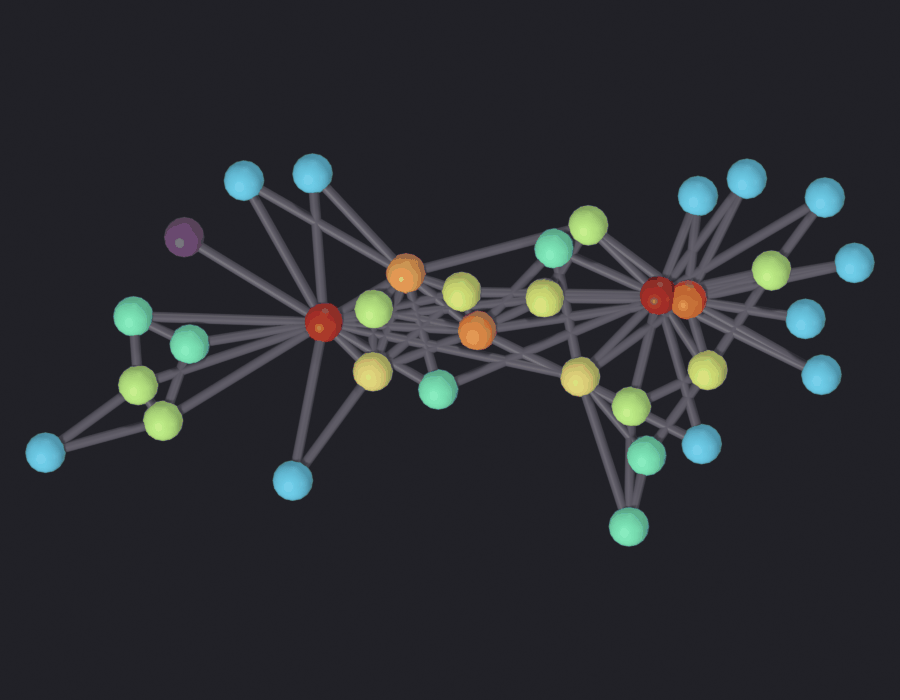

[PASS] 1_karate_degree.png legible — 15.4% ink (healthy range 0.5–60%)
  15.4% ink, of which 41% carries the colormap

betweenness   p0=0.0000  p25=0.0000  p50=0.0026  p75=0.0319  p90=0.1420  p100=0.4376
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_betweenness  ·  centrality_betweenness -> turbo [log]  [0 … 0.4376] on Point


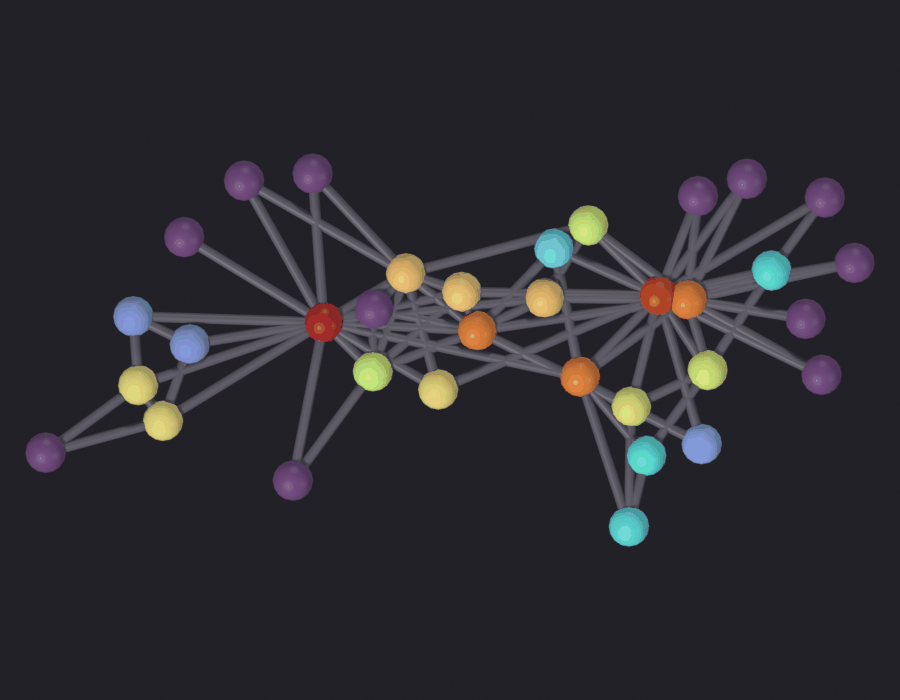

[PASS] 1_karate_betweenness.png legible — 15.3% ink (healthy range 0.5–60%)
  15.3% ink, of which 40% carries the colormap

closeness   p0=0.2845  p25=0.3718  p50=0.3837  p75=0.4802  p90=0.5334  p100=0.5690
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_closeness  ·  centrality_closeness -> turbo [log]  [0.2845 … 0.569] on Point


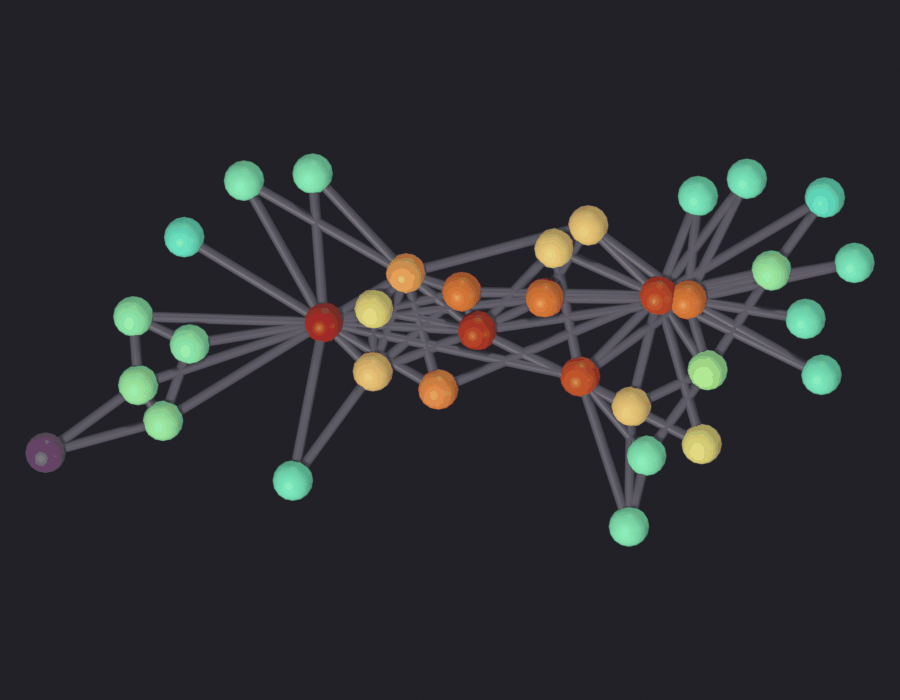

[PASS] 1_karate_closeness.png legible — 15.4% ink (healthy range 0.5–60%)
  15.4% ink, of which 37% carries the colormap

eigenvector   p0=0.0236  p25=0.0807  p50=0.1020  p75=0.1870  p90=0.2958  p100=0.3734
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_eigenvector  ·  centrality_eigenvector -> turbo [log]  [0.02363 … 0.3734] on Point


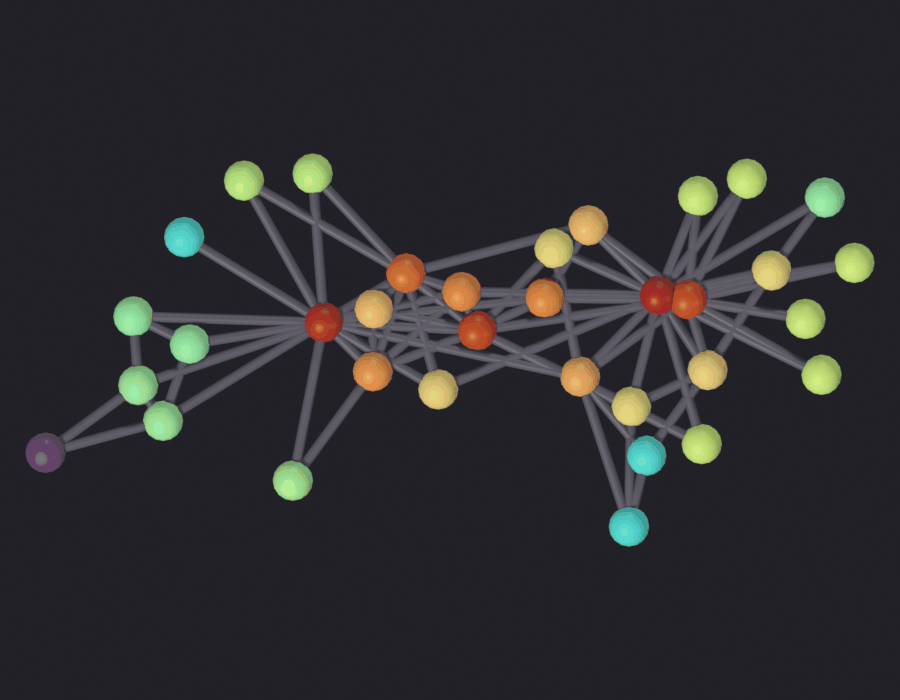

[PASS] 1_karate_eigenvector.png legible — 15.4% ink (healthy range 0.5–60%)
  15.4% ink, of which 36% carries the colormap


In [8]:
for method in METHODS:
    v = centrality[method]
    print(f"\n{method}   " + "  ".join(
          f"p{p}={q:.4f}" for p, q in zip((0, 25, 50, 75, 90, 100),
          np.percentile(v, [0, 25, 50, 75, 90, 100]))))
    figure(karate, f"renders/03_centrality/1_karate_{method}",
           color_attribute=f"centrality_{method}")

Every measure finds the two factions the club actually split
into: the instructor's node and the president's node are the extremes of all
four plates. What separates the measures is everything in between.

Betweenness is also the only one whose *low* end is a hard zero for a large
part of the graph. Those nodes lie on no shortest path between any other
pair, so they share the bottom stop of the ramp and cannot be told apart.

In [9]:
for method in METHODS:
    print(f"nodes at exactly zero {method:<12}: "
          f"{int((centrality[method] == 0).sum()):>3} of {len(karate_order)}")

nodes at exactly zero degree      :   0 of 34
nodes at exactly zero betweenness :  12 of 34
nodes at exactly zero closeness   :   0 of 34
nodes at exactly zero eigenvector :   0 of 34


## 4 · Where the measures disagree

Where the four plates differ, as a rank correlation table. Spearman's ρ,
because none of these measures is on a comparable scale and only the ordering
matters.

In [10]:
def rank_table(values, label, width=11):
    """Print the Spearman matrix and return it as {(a, b): rho}."""
    keys = list(values)
    pad = max(len(k) for k in keys) + 2
    print(f"Spearman rank correlation: {label}")
    print(" " * pad + "".join(f"{k[:width - 1]:>{width}}" for k in keys))
    matrix = {}
    for a in keys:
        row = []
        for b in keys:
            rho = float(spearmanr(values[a], values[b]).statistic)
            matrix[(a, b)] = rho
            row.append(f"{rho:{width}.3f}")
        print(f"{a:<{pad}}" + "".join(row))
    return matrix


karate_rho = rank_table(centrality, "Zachary's karate club (34 nodes)")

Spearman rank correlation: Zachary's karate club (34 nodes)
                  degree betweennes  closeness eigenvecto
degree             1.000      0.905      0.895      0.777
betweenness        0.905      1.000      0.898      0.694
closeness          0.895      0.898      1.000      0.856
eigenvector        0.777      0.694      0.856      1.000


Read the off-diagonal, not the diagonal.

* Degree and betweenness agree at ρ ≈ 0.90 and still disagree about
  individual nodes, which is why both exist.
* Eigenvector is the odd one out: ρ ≈ 0.69 against betweenness, its lowest
  pairing, ≈ 0.86 against closeness, its highest. It rewards being *near* the
  dense core; betweenness rewards being *between* things.
* Closeness correlates with everything (≈ 0.86 to 0.90) and is the least
  informative column for that reason. On a graph of diameter 5 a mean hop
  distance has little room to vary: it spans a factor of two, against a
  factor of infinity for betweenness.

In [11]:
off_diagonal = {k: v for k, v in karate_rho.items() if k[0] != k[1]}
lowest = min(off_diagonal, key=off_diagonal.get)
check("eigenvector and betweenness are the least similar pair",
      set(lowest) == {"eigenvector", "betweenness"},
      f"{lowest[0]} vs {lowest[1]}, rho = {off_diagonal[lowest]:.3f}")

closeness_span = centrality["closeness"].max() / centrality["closeness"].min()
degree_span = centrality["degree"].max() / centrality["degree"].min()
check("closeness has the narrowest range of the four",
      closeness_span < degree_span,
      f"closeness spans x{closeness_span:.1f}, degree x{degree_span:.1f}")

[PASS] eigenvector and betweenness are the least similar pair — betweenness vs eigenvector, rho = 0.694
[PASS] closeness has the narrowest range of the four — closeness spans x2.0, degree x17.0


True

### The nodes betweenness ranks highly that degree does not

A node with two or three neighbors and a high betweenness is a bridge: cut
it and the graph falls in two. Degree cannot see that.

In [12]:
def rank_of(values):
    """1-based rank, highest value first."""
    return (-np.asarray(values)).argsort().argsort() + 1


rank_degree = rank_of(centrality["degree"])
rank_between = rank_of(centrality["betweenness"])
climb = rank_degree - rank_between

print(f"{'node':>5} {'degree':>8} {'rank':>5} {'betweenness':>12} {'rank':>5} "
      f"{'climb':>6} {'neighbors':>11}")
for i in np.argsort(-climb)[:6]:
    node = karate_order[i]
    print(f"{node:>5} {centrality['degree'][i]:8.4f} {rank_degree[i]:5d} "
          f"{centrality['betweenness'][i]:12.4f} {rank_between[i]:5d} "
          f"{climb[i]:+6d} {KARATE.degree(node):11d}")

bridge = int(np.argmax(climb))
print(f"\nnode {karate_order[bridge]} has {KARATE.degree(karate_order[bridge])} "
      f"neighbors and is ranked {rank_between[bridge]} of {len(karate_order)} "
      f"by betweenness, against {rank_degree[bridge]} by degree")

check("betweenness promotes a low-degree bridge over higher-degree nodes",
      climb.max() >= 5, f"largest climb {climb.max():+d} places")

 node   degree  rank  betweenness  rank  climb   neighbors
   19   0.0909    18       0.0325     9     +9           3
   14   0.0606    32       0.0000    24     +8           2
    5   0.1212    15       0.0300    10     +5           4
    8   0.1515    10       0.0559     6     +4           5
    9   0.0606    23       0.0008    20     +3           2
    6   0.1212    14       0.0300    11     +3           4

node 19 has 3 neighbors and is ranked 9 of 34 by betweenness, against 18 by degree
[PASS] betweenness promotes a low-degree bridge over higher-degree nodes — largest climb +9 places


True

## 5 · Distributions, and why `clip_high_pct` exists

The karate club is small enough for a linear ramp. `barabasi_albert_graph(150,
2)` grows by preferential attachment, so its degree distribution has a heavy
tail by construction, and its *betweenness* distribution is heavier still: a
hub is the only route between the branches hanging off it.

In [13]:
sg.graphs.activate(scalefree)
for method in ("degree", "betweenness"):
    bpy.ops.scigraphs.calculate_centrality(method=method)

sf_gd = parsed["BarabasiAlbert"]
sf = {m: np.array(analysis.calculate_centrality(sf_gd, method=m))
      for m in ("degree", "betweenness")}

for method, values in sf.items():
    order = np.sort(values)[::-1]
    print(f"\n{method}")
    print("  " + "  ".join(f"p{p}={np.percentile(values, p):.5f}"
          for p in (50, 75, 90, 95, 98, 99, 100)))
    print(f"  top 3 nodes hold {order[:3].sum() / values.sum() * 100:5.1f}% of the total")
    print(f"  max / median      x{values.max() / np.median(values):.0f}")

skew = {m: v.max() / np.median(v) for m, v in sf.items()}
check("betweenness is far more skewed than degree",
      skew["betweenness"] > 3 * skew["degree"],
      f"x{skew['betweenness']:.0f} against x{skew['degree']:.0f}")

Info: Centrality 'degree' calculated
Info: Centrality 'betweenness' calculated

degree
  p50=0.02013  p75=0.03188  p90=0.04698  p95=0.07081  p98=0.08738  p99=0.10423  p100=0.18792
  top 3 nodes hold  10.0% of the total
  max / median      x9

betweenness
  p50=0.00443  p75=0.01492  p90=0.03855  p95=0.06890  p98=0.09626  p99=0.11633  p100=0.36246
  top 3 nodes hold  24.6% of the total
  max / median      x82
[PASS] betweenness is far more skewed than degree — x82 against x9


True

Mapped linearly, that puts one node at the top of turbo and
compresses the other 149 into the bottom. The percentile clip is the only fix
that works here.

> **`vmin=` and `vmax=` are silently ineffective.**
> `scigraphs.color_set_attribute` calls `fn.update_property_range(props, obj,
> target)` immediately before `apply_coloring`
> (`SciGraphs/ui/coloring/operators.py:374`), overwriting both with the
> attribute's own extremes. Nothing is reported. Two centralities cannot be
> put on one shared absolute scale through this path.

The graph needs its visualization built before the coloring operator has
anything to wire into, which `render_eevee` normally does on the way past.

In [14]:
sg.render.autoscale_geometry(scalefree, node_fraction=0.35, verbose=False)
sg.render.material(scalefree)
sg.render.geometry_nodes(scalefree)
sg.render.color_graph(scalefree, "centrality_betweenness", colormap="turbo",
                      vmin=0.0, vmax=1.0, verbose=False)

applied = sg.render.color_range(scalefree)
print("asked for vmin/vmax  (0.0, 1.0)")
print(f"actually mapped      ({applied[0]:.6f}, {applied[1]:.6f})")
print(f"attribute extremes   ({sf['betweenness'].min():.6f}, "
      f"{sf['betweenness'].max():.6f})")
check("vmin/vmax were overwritten by the attribute's own range",
      abs(applied[1] - sf["betweenness"].max()) < 1e-4,
      "clip_low_pct / clip_high_pct are the controls that work")

Info: Geometry Nodes modifier added
Info: Attribute -> centrality_betweenness  ·  centrality_betweenness -> turbo [log]  [0 … 0.3625] on Point
asked for vmin/vmax  (0.0, 1.0)
actually mapped      (0.000000, 0.362459)
attribute extremes   (0.000000, 0.362459)
[PASS] vmin/vmax were overwritten by the attribute's own range — clip_low_pct / clip_high_pct are the controls that work


True

Three plates, one variable at a time. First the defaults: a
linear ramp over the raw range and the house `node_fraction` of 0.35.

Info: Geometry Nodes modifier added
Info: Attribute -> centrality_betweenness  ·  centrality_betweenness -> turbo [log]  [0 … 0.3625] on Point


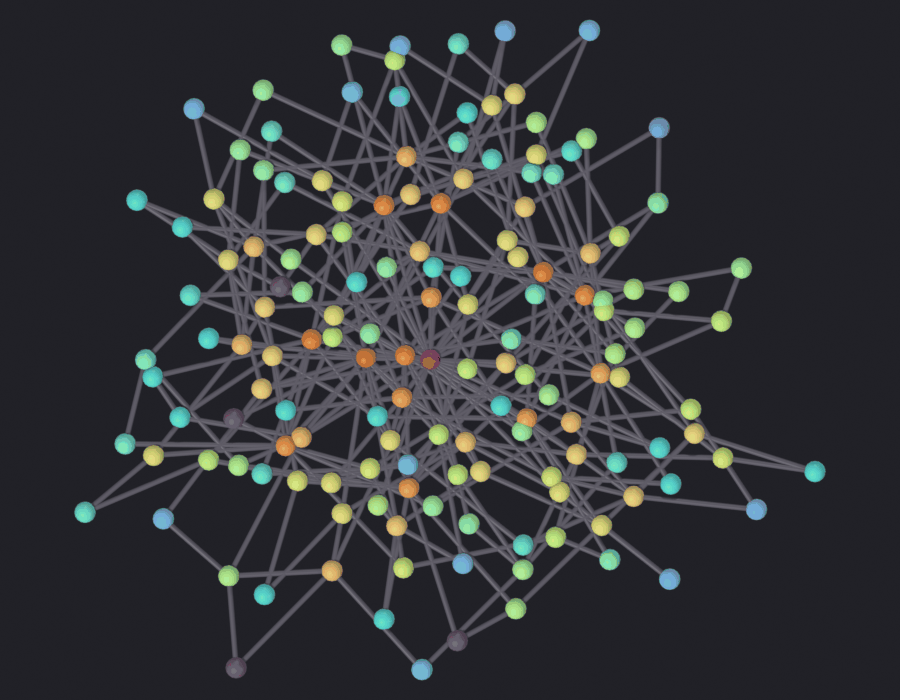

[PASS] 2_ba_default.png legible — 26.5% ink (healthy range 0.5–60%)
  26.5% ink, of which 26% carries the colormap


In [15]:
figure(scalefree, "renders/03_centrality/2_ba_default",
       color_attribute="centrality_betweenness")

One warm node and a field of purple. Correct, and it says only
"there is a hub". Now the clip alone, at the 98th percentile, sizing
unchanged.

clipping at p98 = 0.09626, against a maximum of 0.36246
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_betweenness  ·  centrality_betweenness -> turbo [log]  [0 … 0.09626] on Point


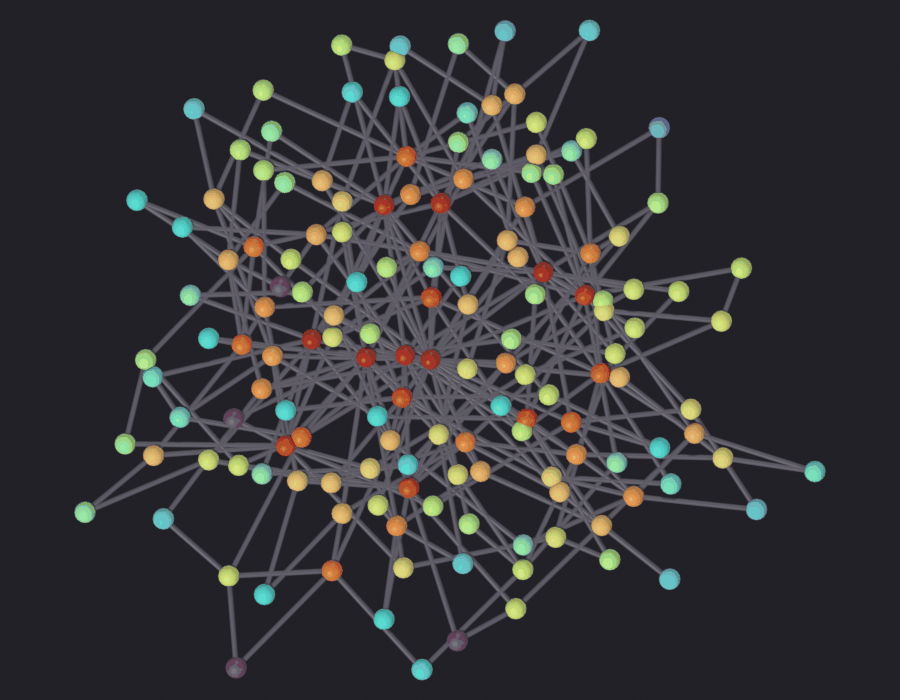

[PASS] 3_ba_clip98.png legible — 26.5% ink (healthy range 0.5–60%)
  26.5% ink, of which 27% carries the colormap


In [16]:
print(f"clipping at p98 = {np.percentile(sf['betweenness'], 98):.5f}, "
      f"against a maximum of {sf['betweenness'].max():.5f}")
figure(scalefree, "renders/03_centrality/3_ba_clip98",
       color_attribute="centrality_betweenness", clip_high_pct=98)

The ramp is now spent on the 98 % of the graph the first plate
threw away, and the tree-like periphery becomes readable: chains of blue out
to the leaves are nodes with real betweenness that the linear scale flattened
onto the floor. The cost is the top, where every node above the 98th
percentile is the same red, so the plate can no longer say *which* hub is
biggest. Hence the percentiles printed above the figure.

> `nb.check_render` cannot adjudicate this. Clipping moves colors around
> without changing how many pixels carry them, so both plates come back at
> essentially the same ink.

Then the sizing. At `node_fraction=0.35`, 150 nodes of mean degree 4 put four
tubes in the frame for every sphere. At 0.5, with the tube ratio pinned to
0.12 instead of the derived 0.25, the figure is about the nodes again; the
ink fraction barely moves, so the legibility check cannot see it either.

Info: Geometry Nodes modifier added
Info: Attribute -> centrality_betweenness  ·  centrality_betweenness -> turbo [log]  [0 … 0.09626] on Point


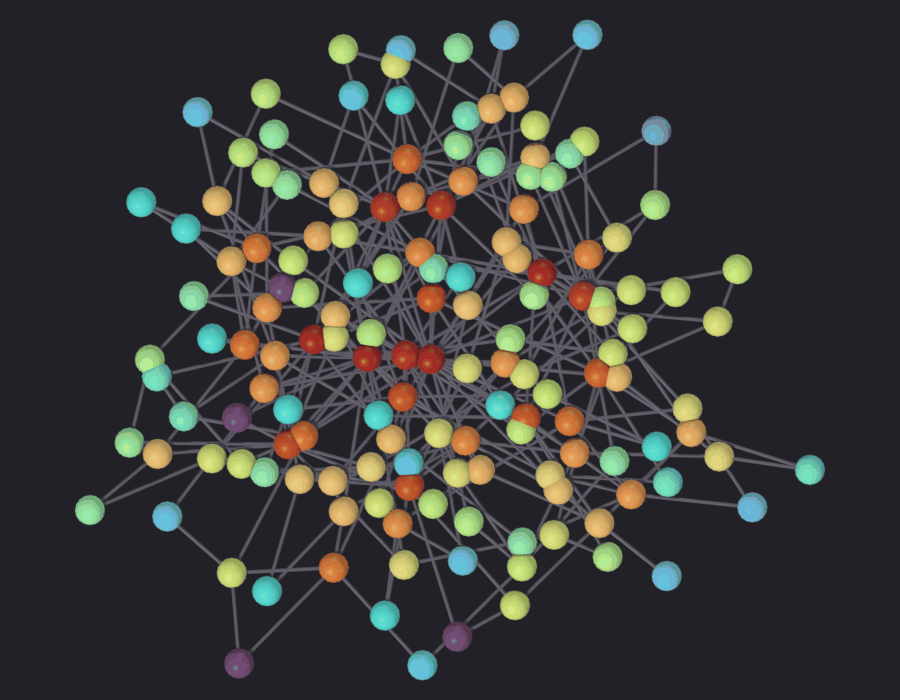

[PASS] 4_ba_clip98_sized.png legible — 27.0% ink (healthy range 0.5–60%)
  27.0% ink, of which 52% carries the colormap


In [17]:
figure(scalefree, "renders/03_centrality/4_ba_clip98_sized",
       color_attribute="centrality_betweenness", clip_high_pct=98,
       node_fraction=0.5, edge_ratio=0.12)

## 6 · Directed against undirected

`calculate_directed_centrality` refuses to run unless `obj["is_directed"]` is
set (`analysis_operators.py:205`). Its six methods
(`splitter_properties.py:242`) are PageRank, HITS hub, HITS authority,
in-degree, out-degree and Katz. The method comes from
`scene.scigraphs.directed_centrality_method` rather than an operator
property, so from a script that scene property is the only way to choose one.

In [18]:
DIRECTED_METHODS = ('pagerank', 'hub_score', 'authority_score',
                    'in_degree', 'out_degree', 'katz')

sg.graphs.activate(directed)
directed_gd = parsed["DirectedScaleFree"]
directed_values = {}

# Two of the six need this: `nx.hits` starts ARPACK from an unseeded random
# vector and nothing in SciGraphs seeds it. Measured after the table.
np.random.seed(17)

for method in DIRECTED_METHODS:
    bpy.context.scene.scigraphs.directed_centrality_method = method
    result = bpy.ops.scigraphs.calculate_directed_centrality()
    directed_values[method] = np.array(
        analysis.calculate_directed_centrality(directed_gd, method=method))
    print(f"{method:16} {'/'.join(result):10} ->  directed_{method}")

reciprocal = sum(1 for u, v in DIRECTED.edges() if DIRECTED.has_edge(v, u))
print(f"\nreciprocal edges: {reciprocal} of {DIRECTED.number_of_edges()}; "
      f"{100 * (1 - reciprocal / DIRECTED.number_of_edges()):.0f}% of this "
      f"graph is one-way")

Info: Directed centrality 'pagerank' calculated
pagerank         FINISHED   ->  directed_pagerank
Info: Directed centrality 'hub_score' calculated
hub_score        FINISHED   ->  directed_hub_score
Info: Directed centrality 'authority_score' calculated
authority_score  FINISHED   ->  directed_authority_score
Info: Directed centrality 'in_degree' calculated
in_degree        FINISHED   ->  directed_in_degree
Info: Directed centrality 'out_degree' calculated
out_degree       FINISHED   ->  directed_out_degree
Info: Directed centrality 'katz' calculated
katz             FINISHED   ->  directed_katz

reciprocal edges: 16 of 197; 92% of this graph is one-way


### The undirected operator does symmetrize, silently

`calculate_centrality` on the same directed object returns exactly
`nx.degree_centrality` of the underlying undirected graph: direction
discarded, reciprocal pairs collapsed onto one edge. No warning, and
`is_directed` is never consulted on that path.

In [19]:
undirected_degree = np.array(
    analysis.calculate_centrality(directed_gd, method='degree'))
symmetrized = np.array([nx.degree_centrality(DIRECTED.to_undirected())[n]
                       for n in directed_order])

check("calculate_centrality on a directed graph == the symmetrized graph",
      float(np.abs(undirected_degree - symmetrized).max()) < 1e-12,
      "`nx.Graph()` at analysis.py:16, whatever is_directed says")

rho = float(spearmanr(undirected_degree, directed_values['pagerank']).statistic)
print(f"\nSpearman(undirected degree, PageRank) = {rho:.3f}")
print("The two orderings share about half their information. On a directed "
      "graph they answer different questions, and only one of the two "
      "operators knows the graph is directed.")

[PASS] calculate_centrality on a directed graph == the symmetrized graph — `nx.Graph()` at analysis.py:16, whatever is_directed says

Spearman(undirected degree, PageRank) = 0.565
The two orderings share about half their information. On a directed graph they answer different questions, and only one of the two operators knows the graph is directed.


The rank correlations among the directed measures, with the
symmetrized degree as a control column.

In [20]:
SHORT = {'pagerank': 'pagerank', 'hub_score': 'hub', 'authority_score': 'authority',
         'in_degree': 'in_deg', 'out_degree': 'out_deg', 'katz': 'katz'}
directed_table = {SHORT[k]: v for k, v in directed_values.items()}
directed_table['undirected'] = undirected_degree
directed_rho = rank_table(directed_table,
                          "directed scale-free (120 nodes)", width=10)

Spearman rank correlation: directed scale-free (120 nodes)
              pagerank       hub authority    in_deg   out_deg      katz undirecte
pagerank         1.000    -0.067     0.848     0.993    -0.077     0.999     0.565
hub             -0.067     1.000    -0.043    -0.062     0.819    -0.071     0.502
authority        0.848    -0.043     1.000     0.841    -0.097     0.859     0.450
in_deg           0.993    -0.062     0.841     1.000    -0.068     0.993     0.583
out_deg         -0.077     0.819    -0.097    -0.068     1.000    -0.082     0.649
katz             0.999    -0.071     0.859     0.993    -0.082     1.000     0.562
undirected       0.565     0.502     0.450     0.583     0.649     0.562     1.000


Three things fall out of that table.

* PageRank tracks in-degree, not out-degree: a random surfer follows links
  *forward*, so it accumulates where links point.
* Authority tracks in-degree and hub tracks out-degree, as HITS is defined to
  do. Each is computed from its own `nx.hits(G, max_iter=1000)` call
  (`analysis.py:347` and `:355`), so asking for both runs the same iteration
  twice and throws half of each result away.
* The symmetrized degree correlates decently with everything and matches
  nothing, which is the argument for a directed operator at all.

One more, undocumented: Katz and PageRank agree to three decimal places here
(ρ = 0.999), and both agree with plain in-degree at 0.993. On a graph this
sparse (197 edges over 120 nodes, 92 % one-way) the recursive measures have
almost nothing to recurse through and all three collapse onto "how many
arrows point at me". They separate on a denser graph; here, running all six
costs six iterations and yields three answers.

In [21]:
check("Katz and PageRank agree almost exactly on this sparse graph",
      directed_rho[('katz', 'pagerank')] > 0.99,
      f"rho = {directed_rho[('katz', 'pagerank')]:.4f}")
check("PageRank sits closer to in-degree than to out-degree",
      directed_rho[('pagerank', 'in_deg')] > directed_rho[('pagerank', 'out_deg')],
      f"{directed_rho[('pagerank', 'in_deg')]:.3f} against "
      f"{directed_rho[('pagerank', 'out_deg')]:.3f}")
check("hub tracks out-degree and authority tracks in-degree",
      directed_rho[('hub', 'out_deg')] > directed_rho[('hub', 'in_deg')]
      and directed_rho[('authority', 'in_deg')] > directed_rho[('authority', 'out_deg')])

[PASS] Katz and PageRank agree almost exactly on this sparse graph — rho = 0.9992
[PASS] PageRank sits closer to in-degree than to out-degree — 0.993 against -0.077
[PASS] hub tracks out-degree and authority tracks in-degree


True

### Two of those columns are not reproducible

The `hub` and `authority` rows move between runs on the same graph with
nothing changed: two consecutive runs rank the nodes at a Spearman ρ well
under 1 against *each other*, a wider gap than the one separating two of the
six measures.

NetworkX 3.6 computes HITS as a one-singular-value decomposition,
`scipy.sparse.linalg.svds(A, k=1, maxiter=..., tol=...)`, and passes a
starting vector only when the caller supplies `nstart`. SciGraphs calls
`nx.hits(G, max_iter=1000)` with no `nstart` (`analysis.py:347` for hub,
`:355` for authority), so ARPACK starts from an unseeded random vector.

The *values* are reproducible to about 1e-16; the *ranking* is not. Most of
this graph has an authority score that is numerically zero, and sorting 88
zeros by their 1e-17 of floating-point noise gives a different order every
time. Seeding NumPy's global RNG immediately before the call pins it.

In [22]:
def hits_authority():
    scores = nx.hits(DIRECTED, max_iter=1000)[1]
    return np.array([scores[n] for n in directed_order])


unseeded = [hits_authority() for _ in range(3)]
np.random.seed(17)
seeded_a = hits_authority()
np.random.seed(17)
seeded_b = hits_authority()

print(f"authority scores below 1e-12: {int((np.abs(unseeded[0]) < 1e-12).sum())} "
      f"of {len(unseeded[0])} nodes")
print(f"largest value difference between two unseeded runs: "
      f"{np.abs(unseeded[0] - unseeded[1]).max():.1e}")
for i in (1, 2):
    print(f"Spearman(run 0, run {i}) unseeded : "
          f"{spearmanr(unseeded[0], unseeded[i]).statistic:.3f}")
print(f"Spearman(run 0, run 1) seeded   : "
      f"{spearmanr(seeded_a, seeded_b).statistic:.3f}")

drift = min(float(spearmanr(unseeded[0], unseeded[i]).statistic) for i in (1, 2))
check("unseeded HITS gives the same values in a different order",
      drift < 0.999 and np.abs(unseeded[0] - unseeded[1]).max() < 1e-12,
      f"worst rank agreement between two runs: {drift:.3f}")
check("seeding numpy before the call makes it reproducible",
      spearmanr(seeded_a, seeded_b).statistic == 1.0)

authority scores below 1e-12: 88 of 120 nodes
largest value difference between two unseeded runs: 1.4e-16
Spearman(run 0, run 1) unseeded : 0.960
Spearman(run 0, run 2) unseeded : 0.920
Spearman(run 0, run 1) seeded   : 1.000
[PASS] unseeded HITS gives the same values in a different order — worst rank agreement between two runs: 0.920
[PASS] seeding numpy before the call makes it reproducible


True

### The in- and out-degree normalization is not the standard
one

`nx.in_degree_centrality` divides by `n - 1`, so the value is the fraction of
the graph pointing at this node and two graphs can be compared. The operator
divides by the largest in-degree in this graph (`analysis.py:362` to `:363`,
and `:367` to `:368` for out-degree), so the busiest node is always exactly
1.0 and the scale is graph-relative. The enum description says only "Number
of incoming connections (popularity)".

It is a rescaling, so the rank table above still holds; an absolute reading
of the number does not.

In [23]:
print(f"operator in_degree  max = {directed_values['in_degree'].max():.4f}")
print(f"networkx in_degree  max = {max(nx.in_degree_centrality(DIRECTED).values()):.4f}")
check("the operator's in-degree is normalized to its own maximum",
      abs(directed_values['in_degree'].max() - 1.0) < 1e-9)

operator in_degree  max = 1.0000
networkx in_degree  max = 0.2773
[PASS] the operator's in-degree is normalized to its own maximum


True

> **And it divides by zero on an edgeless directed graph.**
> `max_in` is 0 when nothing has an incoming edge, and the guard above (`if
> in_deg.values() else 1`) only catches an empty *dict*, not a dict of zeros
> (`analysis.py:362` and `:367`). A directed graph with no edges (a failed
> import, a filter that matched nothing) raises `ZeroDivisionError` instead
> of returning zeros.

In [24]:
class _Edgeless:
    nodes = [str(i) for i in range(5)]
    edges = []


try:
    analysis.calculate_directed_centrality(_Edgeless(), method='in_degree')
    raised = None
except Exception as exc:  # noqa: BLE001 - the point is which exception
    raised = type(exc).__name__
check("an edgeless directed graph raises rather than returning zeros",
      raised == "ZeroDivisionError", f"raised {raised}")

[PASS] an edgeless directed graph raises rather than returning zeros — raised ZeroDivisionError


True

PageRank on the directed graph, clipped at the 98th percentile
for the same reason the Barabási-Albert plate was: a scale-free in-degree
gives a scale-free PageRank.

PageRank  p50=0.0026  p90=0.0173  p98=0.0722  p100=0.1159
Info: Geometry Nodes modifier added
Info: Attribute -> directed_pagerank  ·  directed_pagerank -> turbo [log]  [0.002566 … 0.07218] on Point


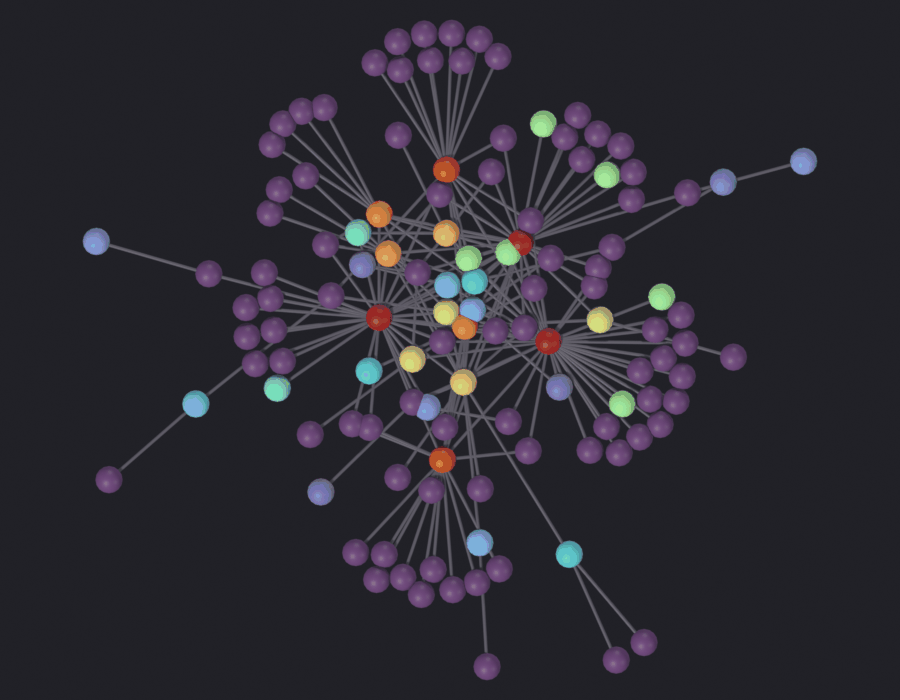

[PASS] 5_directed_pagerank.png legible — 17.7% ink (healthy range 0.5–60%)
  17.7% ink, of which 47% carries the colormap


In [25]:
pagerank = directed_values['pagerank']
print("PageRank  " + "  ".join(f"p{p}={np.percentile(pagerank, p):.4f}"
      for p in (50, 90, 98, 100)))
figure(directed, "renders/03_centrality/5_directed_pagerank",
       color_attribute="directed_pagerank", clip_high_pct=98,
       node_fraction=0.5, edge_ratio=0.12)

> There are no arrows in that figure and there cannot be: the
> tube between two nodes is one piece of swept geometry with no head, so a
> directed graph and its symmetrization draw identically. Only the color
> carries the direction.

## 7 · Strong components, and a cycle count that is not one

`find_sccs` writes an `scc_id` per node and the totals onto the object. On a
scale-free directed graph almost every component is a single node: the graph
grows outward, so there is nothing to come back on.

In [26]:
result = bpy.ops.scigraphs.find_sccs()
print("find_sccs", "/".join(result))
print(f"  components   {directed['num_sccs']}")
print(f"  largest      {directed['largest_scc']} nodes")
print(f"  singletons   {sum(1 for c in nx.strongly_connected_components(DIRECTED) if len(c) == 1)}")

check("scc_id agrees with networkx",
      directed["num_sccs"] == nx.number_strongly_connected_components(DIRECTED))

  Rebuilt simple GN tree (attribute stripping updated)
Info: Found 106 strongly connected components, largest: 15 nodes
find_sccs FINISHED
  components   106
  largest      15 nodes
  singletons   105
[PASS] scc_id agrees with networkx


True

`detect_patterns` writes eight booleans and counts onto the
object. Seven are one NetworkX predicate each and are exactly right. The
eighth is not.

> **`pattern_num_cycles` is capped at 1000, but the cap is applied after
> enumerating every cycle.** `analysis.py:411` is
> `cycles = list(nx.simple_cycles(G))`, and only the *next* line slices it to
> `[:1000]`. The comment says "Limit to 1000 to avoid performance issues";
> the limit avoids nothing. Cycle counts grow super-exponentially with
> density, so on this 120-node graph the operator materializes a list and
> then discards part of it, and on a moderately denser one it does not return
> at all. `nx.simple_cycles` is a generator and `itertools.islice` would have
> made the comment true.

In [27]:
true_cycles = sum(1 for _ in itertools.islice(nx.simple_cycles(DIRECTED), 200_000))
result = bpy.ops.scigraphs.detect_patterns()
print("detect_patterns", "/".join(result))
for key in sorted(k for k in directed.keys() if k.startswith("pattern_")):
    print(f"  {key[8:]:<36} {directed[key]}")

print(f"\nsimple cycles actually enumerated: {true_cycles}")
print(f"reported as pattern_num_cycles   : {directed['pattern_num_cycles']}")
check("the reported cycle count is the cap, not the count",
      directed["pattern_num_cycles"] == min(true_cycles, 1000)
      and true_cycles > 1000,
      f"{true_cycles} enumerated, {directed['pattern_num_cycles']} reported")

Info: 1000 cycles
detect_patterns FINISHED
  has_cycles                           True
  is_dag                               False
  is_forest                            False
  is_strongly_connected                False
  is_tree                              False
  is_weakly_connected                  True
  num_cycles                           1000
  num_strongly_connected_components    106
  num_weakly_connected_components      1

simple cycles actually enumerated: 1210
reported as pattern_num_cycles   : 1000
[PASS] the reported cycle count is the cap, not the count — 1210 enumerated, 1000 reported


True

## 8 · Two operators called "clustering", measuring different
things

The naming trap in the panel:

| Operator | Question | Answer |
|---|---|---|
| `calculate_clustering` | *how cliquey is the neighborhood of this node?* | one float per node, in [0, 1] |
| `apply_clustering` | *which group does this node belong to?* | one integer label per node |

The first is the **local clustering coefficient**: of all the pairs of my
neighbors, what fraction are joined to each other. The second is **community
detection**. They sit one word apart in the panel, and `apply_clustering`
also writes the *coefficient* under a third name, `node_clustering`
(`analysis_operators.py:170`), so the same quantity ends up on the mesh twice.

In [28]:
sg.graphs.activate(karate)
print(bpy.ops.scigraphs.calculate_clustering(), "->  'clustering'")

coefficient = np.array(analysis.calculate_clustering(karate_gd))
print(f"\nlocal clustering coefficient: min {coefficient.min():.3f}  "
      f"median {np.median(coefficient):.3f}  max {coefficient.max():.3f}")
print(f"nodes with a fully connected neighborhood: "
      f"{int((coefficient == 1.0).sum())}")
print(f"global transitivity (networkx): {nx.transitivity(KARATE):.4f}")

  Rebuilt simple GN tree (attribute stripping updated)
Info: Clustering attribute created
{'FINISHED'} ->  'clustering'

local clustering coefficient: min 0.000  median 0.500  max 1.000
nodes with a fully connected neighborhood: 11
global transitivity (networkx): 0.2557


Those last two numbers are not the same quantity: the *median
local* coefficient is 0.5, the *global* transitivity 0.26. The average of a
per-node ratio is not the ratio of the totals. A degree-2 leaf whose two
neighbors are joined scores 1.0 and contributes one triangle; a hub with
twenty neighbors scores near zero and contributes a hundred and ninety open
triples. A paper reporting "the clustering coefficient of this network"
usually means the global one, which lives in
`scigraphs.calculate_global_statistics` and lands on the object as
`stat_global_clustering` alongside five other whole-graph numbers.

In [29]:
print(bpy.ops.scigraphs.calculate_global_statistics())
for key in sorted(k for k in karate.keys() if k.startswith("stat_")):
    print(f"  {key[5:]:<20} {karate[key]}")

check("stat_global_clustering is the transitivity, not the node average",
      abs(karate["stat_global_clustering"] - nx.transitivity(KARATE)) < 1e-9,
      f"{karate['stat_global_clustering']:.4f} against a median local "
      f"coefficient of {np.median(coefficient):.4f}")

Info: Calculating statistics...
Info: Statistics calculated: density=0.139, clustering=0.256, diameter=5
{'FINISHED'}
  assortativity        -0.47561309768461413
  avg_path_length      2.408199643493761
  degree_max           17
  degree_mean          4.588235294117647
  degree_median        3.0
  degree_min           1
  degree_std           3.820360677912828
  density              0.13903743315508021
  diameter             5
  global_clustering    0.2556818181818182
[PASS] stat_global_clustering is the transitivity, not the node average — 0.2557 against a median local coefficient of 0.5000


True

Its correlation with the centralities, because the obvious
guess (that a hub is cliquey) is backward. A hub joins parts of the graph
that are *not* otherwise joined.

In [30]:
with_coefficient = dict(centrality)
with_coefficient["clustering"] = coefficient
rank_table(with_coefficient, "karate, centralities and clustering coefficient")

rho = float(spearmanr(coefficient, centrality["degree"]).statistic)
check("the clustering coefficient is anti-correlated with degree",
      rho < 0, f"rho = {rho:.3f}")

Spearman rank correlation: karate, centralities and clustering coefficient
                  degree betweennes  closeness eigenvecto clustering
degree             1.000      0.905      0.895      0.777     -0.530
betweenness        0.905      1.000      0.898      0.694     -0.730
closeness          0.895      0.898      1.000      0.856     -0.636
eigenvector        0.777      0.694      0.856      1.000     -0.383
clustering        -0.530     -0.730     -0.636     -0.383      1.000
[PASS] the clustering coefficient is anti-correlated with degree — rho = -0.530


True

## 9 · The partition, and how to judge one

`apply_clustering` offers seven backends from the pySurprise wheel
(`analysis_operators.py:114` to `:126`). On this 34-node graph they return
between three and nineteen groups.

> **The default backend cannot be run.** `rn` is the operator's default, and
> is implemented as a scan over 25 resolution values through igraph's Leiden
> algorithm with `n_iterations=-1` (`pysurprise/algorithms.py:400` to `:411`,
> in the bundled wheel). `community_leiden(objective_function="CPM",
> resolution=1.0, n_iterations=-1)` **does not return** on Zachary's karate
> club under igraph 0.11.9: measured at over 400 s, against 0.00007 s for the
> identical call with `n_iterations=2`. γ = 1.0 is the sixteenth step of the
> scan, so every `rn` call on any graph reaches it and stops there.
>
> SciGraphs passes `timeout=300` (`analysis.py:195`) and it does nothing,
> because `rn` never spawns a process; the argument is only honored by the
> five backends that shell out to a binary. The operator runs on Blender's
> main thread, so the result is a frozen Blender with no way back. **This
> notebook never calls `rn`.**

In [31]:
print("the operator's default algorithm is",
      repr(bpy.context.scene.scigraphs.clustering_algorithm),
      "(deliberately not used here, see above)")

sg.graphs.activate(karate)
result = bpy.ops.scigraphs.apply_clustering(algorithm='infomap', resolution=1.0)
print("apply_clustering(algorithm='infomap')", "/".join(result))

print("\nattributes it wrote:")
for name, domain, dtype in sg.graphs.attributes(karate):
    if name in ("cluster_id", "cluster_size", "node_clustering",
                "modularity", "surprise"):
        print(f"  {name:<18} {domain:<7} {dtype}")

the operator's default algorithm is 'rn' (deliberately not used here, see above)
  Rebuilt simple GN tree (attribute stripping updated)
Info: INFOMAP: 3 clusters, surprise=17.177, modularity=0.402
apply_clustering(algorithm='infomap') FINISHED

attributes it wrote:
  cluster_id         POINT   INT
  cluster_size       POINT   INT
  node_clustering    POINT   FLOAT
  modularity         POINT   FLOAT
  surprise           POINT   FLOAT


Two of those five are not per-node quantities. `modularity` and
`surprise` are single numbers for the whole partition, broadcast to every
vertex (`analysis_operators.py:171` to `:172`). They then appear in the
coloring attribute menu alongside the real ones, where coloring by either
gives one uniform color.

In [32]:
def node_attribute(obj, name, dtype=np.float32):
    values = np.empty(len(obj.data.vertices), dtype=dtype)
    obj.data.attributes[name].data.foreach_get("value", values)
    return values[:obj["num_nodes"]]


cluster_id = node_attribute(karate, "cluster_id", np.int32)
modularity_attr = node_attribute(karate, "modularity")
node_clustering = node_attribute(karate, "node_clustering")

print(f"cluster_id     {len(set(cluster_id.tolist()))} distinct labels, "
      f"sizes {np.bincount(cluster_id).tolist()}")
print(f"modularity     {modularity_attr[0]:.4f}, identical on all "
      f"{len(modularity_attr)} vertices")

check("`modularity` is a scalar stored on the POINT domain",
      float(np.ptp(modularity_attr)) == 0.0)
check("`node_clustering` is the same thing as `clustering`",
      float(np.abs(node_clustering - coefficient).max()) < 1e-6,
      "one quantity, two attribute names")

cluster_id     3 distinct labels, sizes [12, 5, 17]
modularity     0.4020, identical on all 34 vertices
[PASS] `modularity` is a scalar stored on the POINT domain
[PASS] `node_clustering` is the same thing as `clustering` — one quantity, two attribute names


True

### Judged against the split that actually happened

Zachary recorded which faction each member joined when the club broke up, the
only ground truth in this notebook. The detected partition is finer than the
real split, so the question is whether it *refines* the truth: does every
detected group sit inside one faction.

In [33]:
faction = np.array([1 if KARATE.nodes[n]["club"] == "Officer" else 0
                   for n in karate_order])
position = {node: i for i, node in enumerate(karate_order)}

print(f"{'group':>6} {'size':>5} {'Mr. Hi':>8} {'Officer':>8}")
pure = 0
for group in sorted(set(cluster_id.tolist())):
    members = cluster_id == group
    hi = int((faction[members] == 0).sum())
    officer = int((faction[members] == 1).sum())
    pure += (hi == 0 or officer == 0)
    print(f"{group:>6} {int(members.sum()):>5} {hi:>8} {officer:>8}")

crossing = sum(1 for u, v in KARATE.edges()
               if cluster_id[position[u]] != cluster_id[position[v]])
print(f"\ngroups lying entirely inside one faction: {pure} of "
      f"{len(set(cluster_id.tolist()))}")
print(f"edges crossing a group boundary: {crossing} of "
      f"{KARATE.number_of_edges()}")

 group  size   Mr. Hi  Officer
     0    12       11        1
     1     5        5        0
     2    17        1       16

groups lying entirely inside one faction: 1 of 3
edges crossing a group boundary: 14 of 78


Nearly. The partition splits the instructor's faction in two
and leaves the president's in one piece, then puts two members in the other
faction's group. Those two are the famously ambiguous cases in Zachary's
data, with roughly as many ties across the divide as within it, whose
eventual choice was recorded rather than predicted.

### Modularity, and the resolution parameter that does not
reach it

Modularity scores a partition by how many more edges fall inside the groups
than would in a random graph with the same degrees. It takes a **resolution**
γ: above 1 it penalizes large groups, below 1 the reverse. The operator
exposes that parameter as *"Higher = more communities"*
(`analysis_operators.py:128` to `:134`, scene property at
`splitter_properties.py:363`).

It does not do that. `apply_advanced_clustering` calls
`detect_communities(graph_data, algorithm=algorithm)` with no resolution
argument, because `detect_communities` does not take one (`analysis.py:282`
and `:229`), then hands γ to the **scoring** call alone (`analysis.py:299`).
The slider does not move the partition by one node; it moves the number
printed next to it.

The sweep below gives an identical partition at every γ and a modularity
marching from strongly positive to strongly negative: the same clustering
scored under a harsher and harsher null model.

In [34]:
print(f"{'gamma':>7} {'groups':>7} {'modularity':>12} {'surprise':>10}  partition")
baseline = None
for gamma in (0.25, 0.5, 1.0, 2.0, 4.0):
    out = analysis.apply_advanced_clustering(karate_gd, algorithm='infomap',
                                             resolution=gamma, seed=0)
    ids = tuple(out['cluster_ids'])
    if baseline is None:
        baseline = ids
    print(f"{gamma:7.2f} {out['num_clusters']:7d} {out['modularity']:12.4f} "
          f"{out['surprise']:10.3f}  "
          f"{'identical to gamma=0.25' if ids == baseline else 'CHANGED'}")

check("the resolution parameter does not change the partition",
      ids == baseline,
      "it is applied to nx.community.modularity only, analysis.py:299")

  gamma  groups   modularity   surprise  partition
   0.25       3       0.7159     17.177  identical to gamma=0.25
   0.50       3       0.6113     17.177  identical to gamma=0.25
   1.00       3       0.4020     17.177  identical to gamma=0.25
   2.00       3      -0.0164     17.177  identical to gamma=0.25
   4.00       3      -0.8534     17.177  identical to gamma=0.25
[PASS] the resolution parameter does not change the partition — it is applied to nx.community.modularity only, analysis.py:299


True

The same graph and the same range of γ under NetworkX's
Louvain, which wires the resolution to the detection instead of the score.

In [35]:
print(f"{'gamma':>7} {'groups':>7} {'modularity':>12}")
for gamma in (0.25, 0.5, 1.0, 2.0, 4.0):
    groups = nx.community.louvain_communities(KARATE, resolution=gamma, seed=3)
    print(f"{gamma:7.2f} {len(groups):7d} "
          f"{nx.community.modularity(KARATE, groups):12.4f}")

  gamma  groups   modularity
   0.25       2       0.4036
   0.50       2       0.4036
   1.00       4       0.4439
   2.00       7       0.3701
   4.00      12       0.2411


> **The random seed is dead too.** `apply_advanced_clustering`
> takes `seed` and `threshold`, the operator fills them from
> `scene.scigraphs.clustering_seed` and `clustering_threshold`
> (`analysis_operators.py:157` to `:158`), and neither name appears below the
> signature (`analysis.py:271`). The property promises "0 = random"; the
> partition is fixed, because `communities_from_edges` seeds igraph from its
> own module-level `COMMUNITY_SEED = 20240517` (`analysis.py:9` and `:194`).
> Reproducible, but not by the control that claims to do it.

In [36]:
partitions = {}
for seed in (0, 1, 999):
    out = analysis.apply_advanced_clustering(karate_gd, algorithm='infomap',
                                             resolution=1.0, seed=seed)
    partitions[seed] = tuple(out['cluster_ids'])
check("the seed argument changes nothing",
      len(set(partitions.values())) == 1,
      f"three seeds, {len(set(partitions.values()))} distinct partition(s)")

[PASS] the seed argument changes nothing — three seeds, 1 distinct partition(s)


True

### What the backends do disagree about

Modularity is computed on the same graph for each, so the column is
comparable. `rn` is absent for the reason above.

In [37]:
BACKENDS = ('infomap', 'cpm', 'rb', 'rnsc', 'scluster', 'uvcluster')
print(f"{'backend':<12} {'groups':>7} {'modularity':>12} {'surprise':>10} "
      f"{'largest':>8}")
scores = {}
for backend in BACKENDS:
    out = analysis.apply_advanced_clustering(karate_gd, algorithm=backend,
                                             resolution=1.0, seed=0)
    sizes = np.bincount(np.array(out['cluster_ids']))
    scores[backend] = out
    print(f"{backend:<12} {out['num_clusters']:>7} {out['modularity']:>12.4f} "
          f"{out['surprise']:>10.3f} {int(sizes.max()):>8}")

best_q = max(scores, key=lambda b: scores[b]['modularity'])
best_s = max(scores, key=lambda b: scores[b]['surprise'])
print(f"\nbest modularity: {best_q}    best surprise: {best_s}")
check("the backends disagree about how many groups there are",
      len({scores[b]['num_clusters'] for b in BACKENDS}) > 2,
      f"{sorted(scores[b]['num_clusters'] for b in BACKENDS)}")

backend       groups   modularity   surprise  largest
infomap            3       0.4020     17.177       17
cpm               12       0.3092     23.846        8
rb                 5       0.3998     21.194       11
rnsc              17       0.2230     24.647        6
scluster           7       0.3931     23.659       10
uvcluster         19       0.1912     25.694        6

best modularity: infomap    best surprise: uvcluster
[PASS] the backends disagree about how many groups there are — [3, 5, 7, 12, 17, 19]


True

A backend returning nineteen groups on a 34-node graph has
found *something*, but not the split the club went through, and modularity
says so. Surprise and modularity do not rank the backends the same way
either: they disagree about whether many small dense groups beat a few large
ones.

## 10 · The community figure, and what turbo costs on a label

The color is `cluster_id`, an integer label with no order in it, run through
a continuous ramp: the compromise the house style forces.

turbo separates adjacent integers better than any other colormap in the set:
measured elsewhere in this suite, the closest adjacent pair of 18 clusters
sits **55/765** apart in turbo against 20/765 in viridis. It is still not a
categorical scale. At the handful of groups this partition has, adjacent
labels read; at eighteen they would not, and such a plate says only "the wide
jumps are different groups".

No percentile clip here, for the reason notebook 18 gives: a clip on a label
is not a clip on a tail. `clip_high_pct=98` would fold the top group into the
one below it and quietly delete a community.

3 groups, labels [0, 1, 2]
adjacent labels are 50% of the ramp apart
Info: Geometry Nodes modifier added
Info: Attribute -> cluster_id  ·  cluster_id -> turbo [log]  [0 … 2] on Point


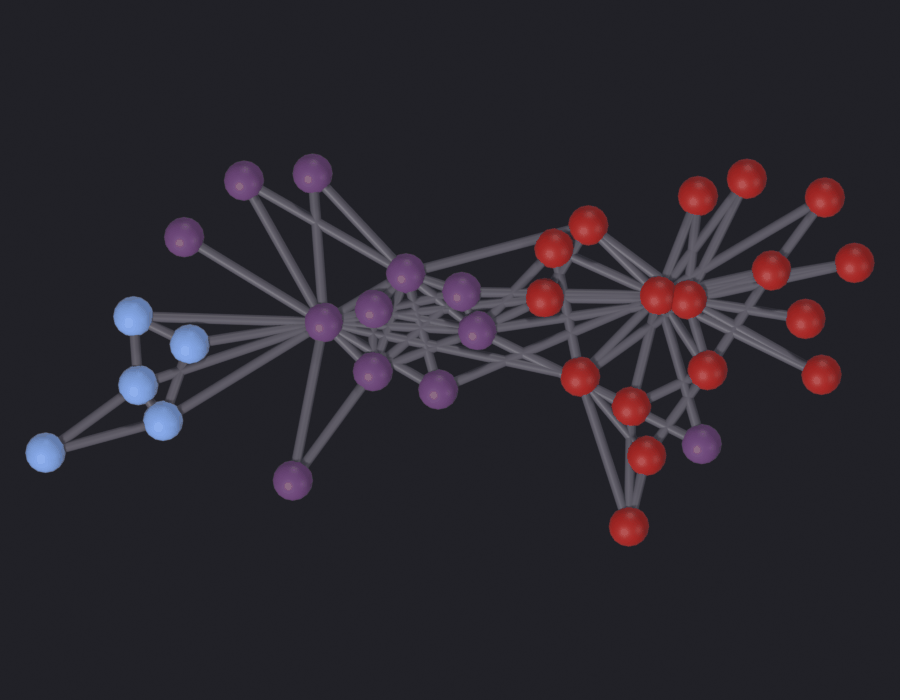

[PASS] 6_karate_communities.png legible — 15.3% ink (healthy range 0.5–60%)
  15.3% ink, of which 41% carries the colormap


In [38]:
labels = sorted(set(cluster_id.tolist()))
print(f"{len(labels)} groups, labels {labels}")
print(f"adjacent labels are {100 / max(len(labels) - 1, 1):.0f}% of the ramp apart")
figure(karate, "renders/03_centrality/6_karate_communities",
       color_attribute="cluster_id")

The two members who ended up in the other faction's group are
visible in that plate: one node of the left group's color inside the right
group's territory, and one of the right group's on the left.

The same graph colored by the clustering coefficient, a genuine continuous
quantity that takes the ramp honestly.

clustering coefficient  p0=0.000  p25=0.333  p50=0.500  p75=1.000  p100=1.000
Info: Geometry Nodes modifier added
Info: Attribute -> clustering  ·  clustering -> turbo [log]  [0 … 1] on Point


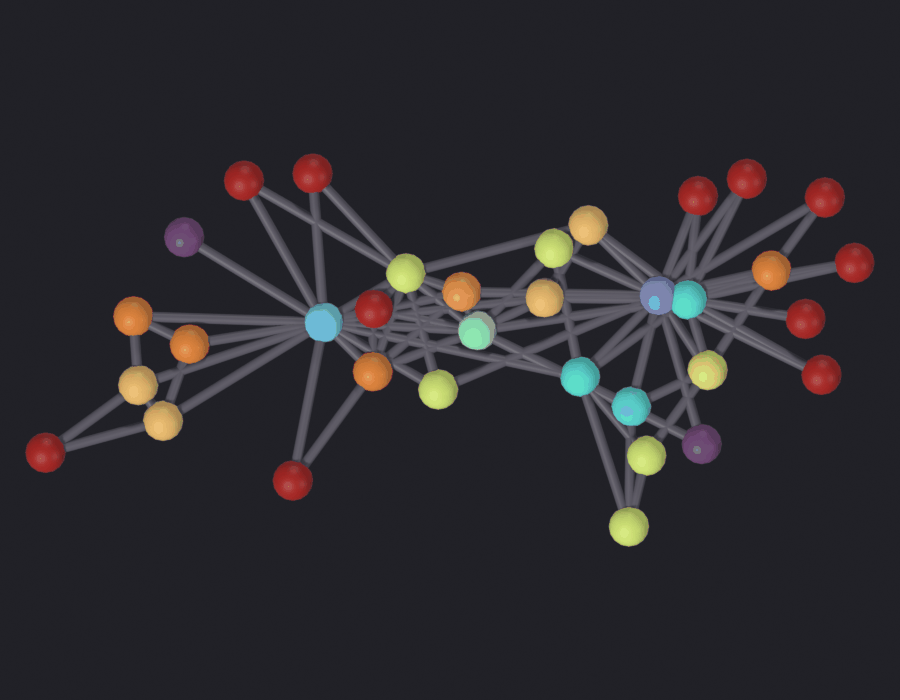

[PASS] 7_karate_clustering_coefficient.png legible — 15.3% ink (healthy range 0.5–60%)
  15.3% ink, of which 40% carries the colormap


In [39]:
print("clustering coefficient  " + "  ".join(
      f"p{p}={np.percentile(coefficient, p):.3f}" for p in (0, 25, 50, 75, 100)))
figure(karate, "renders/03_centrality/7_karate_clustering_coefficient",
       color_attribute="clustering")

## 11 · Order of operations

Every one of these operators ends with
`geometry._rebuild_visualization_if_present(obj)`
(`analysis_operators.py:66`, `:101`, `:181`, `:225`, `:312`, `:355`), and a
rebuild of the Geometry Nodes tree throws the color wiring away, including
the `scigraphs_is_node` marker the color shader gates on. A graph colored
*before* a rebuild comes back uniform gray rather than uncolored.

`nb.render` colors *after* it builds the tree, so the figures
above are safe as written: compute every measure first, then render.
Computing one more centrality between two renders would leave the second
plate gray.

In [40]:
sg.graphs.activate(karate)
bpy.ops.scigraphs.calculate_centrality(method='degree')

modifier = karate.modifiers.get("SciGraphs_Viz")
print(f"SciGraphs_Viz still present : {modifier is not None}")
print(f"visible at render time      : {bool(modifier and modifier.show_render)}")
print(f"color attribute recorded   : "
      f"{karate.get('scigraphs_last_color_attribute')!r}")
print(f"attribute exempt from the strip: {karate.get('scigraphs_color_attr')!r}")

check("the rebuild leaves a modifier that will render",
      modifier is not None and modifier.show_render,
      "what it does not leave is the color wiring, hence color last")

  Rebuilt simple GN tree (attribute stripping updated)
Info: Centrality 'degree' calculated
SciGraphs_Viz still present : True
visible at render time      : True
color attribute recorded   : 'clustering_color'
attribute exempt from the strip: 'clustering'
[PASS] the rebuild leaves a modifier that will render — what it does not leave is the color wiring, hence color last


True

## Rendering

Ten figures, all EEVEE through `nb.render`, all `look='ink'`
with its turbo ramp, all straight down through an orthographic camera.
Notebook 13 explains the path and notebook 15 the choice of look. The PNGs
are left in `notebooks/out/renders/03_centrality/`.

> The Vulkan warning of notebooks 15 and 17 does not apply to any figure
> here, since none goes through the SciGraphs GPU engine. It still applies to
> the viewport: on Blender's **Vulkan** backend, the default on Linux,
> `gpu.state.point_size_set` does nothing for the add-on's shaders, so
> `POINT` and `DISK` nodes draw one pixel wide. Start Blender with
> `--gpu-backend opengl`.

In [41]:
print("figures written:")
for png in sorted(nb.out("renders", "03_centrality").glob("*.png")):
    print(f"  {nb.rel(png):<58} {png.stat().st_size / 1e3:>5.0f} kB")

figures written:
  notebooks/out/renders/03_centrality/1_karate_betweenness.png   173 kB
  notebooks/out/renders/03_centrality/1_karate_closeness.png   172 kB
  notebooks/out/renders/03_centrality/1_karate_degree.png      174 kB
  notebooks/out/renders/03_centrality/1_karate_eigenvector.png   171 kB
  notebooks/out/renders/03_centrality/2_ba_default.png         244 kB
  notebooks/out/renders/03_centrality/3_ba_clip98.png          243 kB
  notebooks/out/renders/03_centrality/4_ba_clip98_sized.png    131 kB
  notebooks/out/renders/03_centrality/5_directed_pagerank.png   204 kB
  notebooks/out/renders/03_centrality/6_karate_communities.png   180 kB
  notebooks/out/renders/03_centrality/7_karate_clustering_coefficient.png   173 kB


## Summary

| Claim on the label | What it does |
|---|---|
| `calculate_centrality`: node centrality | Correct, but always undirected and unweighted |
| `calculate_directed_centrality`: six directed measures | Correct ordering; in/out-degree normalized by the graph's own maximum, and divides by zero on a graph with no edges |
| `calculate_directed_centrality(hub_score / authority_score)` | Values reproducible, *ranking* not: `nx.hits` is called without `nstart`, so ARPACK starts from an unseeded vector |
| `calculate_clustering`: clustering | The local *coefficient*, not a partition |
| `apply_clustering`: clustering | A *partition*, plus the coefficient again under a third name |
| `apply_clustering(resolution=γ)`: "higher = more communities" | Changes the reported modularity only; the partition is identical at every γ |
| `apply_clustering(seed=…)`: "0 = random" | Unused; the seed is fixed at `COMMUNITY_SEED` |
| `apply_clustering(algorithm='rn')`: the default | Does not return; hangs Blender's main thread |
| `detect_patterns`: "limit to 1000 cycles" | Enumerates every cycle, then keeps 1000 |
| `find_sccs` | Correct |

And two about the figures: an orthographic frame has to be solved more than
once or the first plate of a session is cropped, and `vmin`/`vmax` are
overwritten before use, so `clip_low_pct` / `clip_high_pct` are the only
working range controls.

Next to try: `les_miserables_graph()` in place of `karate_club_graph()`, a
*weighted* graph, where these operators ignoring weights becomes visible in
the answer rather than only in the source.

Next: **18 · Paths, trees and flows**.